<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kionc\AppData\Local\Temp\ipykernel_35948\4250376194.py:6: SyntaxWarning: invalid escape sequence '\p'
  df_job_name = pd.read_csv('result\python_related_job_name.csv')
C:\Users\kionc\AppData\Local\Temp\ipykernel_35948\4250376194.py:7: SyntaxWarning: invalid escape sequence '\p'
  df_exact_salary = pd.read_csv('result\python_related_exact_salary.csv')


Total N in new chart: 95


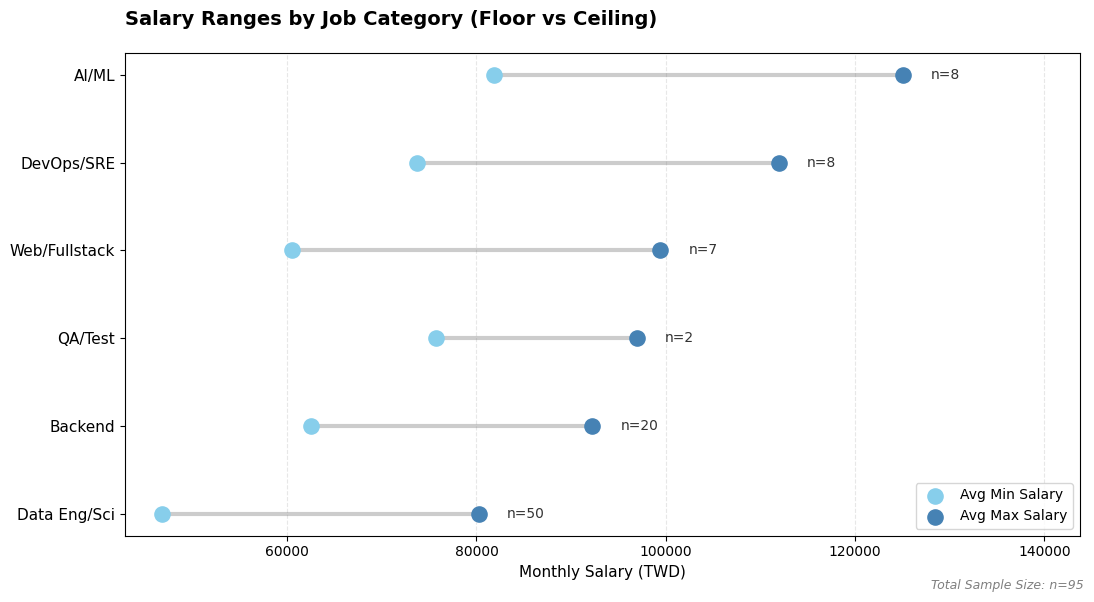

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data (Using the NEW uploaded files)
df_job_name = pd.read_csv('result\python_related_job_name.csv')
df_exact_salary = pd.read_csv('result\python_related_exact_salary.csv')

# 2. Merge Data
df_merged = pd.merge(df_job_name, df_exact_salary, on='_id', how='inner')

# 3. Categorization Logic
def get_category(name):
    name_lower = str(name).lower()
    if any(x in name_lower for x in ['ai', 'machine learning', 'deep learning', '演算法', 'algorithm']):
        return 'AI/ML'
    elif any(x in name_lower for x in ['devops', 'sre', 'cloud', 'aws', 'system', '系統']):
        return 'DevOps/SRE'
    elif any(x in name_lower for x in ['data', '資料', 'etl']):
        return 'Data Eng/Sci'
    elif any(x in name_lower for x in ['backend', '後端', 'server', 'api']):
        return 'Backend'
    elif any(x in name_lower for x in ['frontend', '前端', 'web', 'full stack', 'fullstack', '全端']):
        return 'Web/Fullstack'
    elif any(x in name_lower for x in ['qa', 'test', '測試']):
        return 'QA/Test'
    else:
        return 'Other'

df_merged['category'] = df_merged['job_name'].apply(get_category)

# 4. Aggregation (Calculate Mean Min & Max Salary)
path1_stats = df_merged.groupby('category').agg(
    Avg_Min=('salaryMin', 'mean'),
    Avg_Max=('salaryMax', 'mean'),
    Job_Count=('salaryMin', 'count')
).reset_index()

# Filter out 'Other' for cleaner visualization
path1_stats = path1_stats[path1_stats['category'] != 'Other']

# Sort by Avg Max Salary (Top salary at top)
path1_stats_sorted = path1_stats.sort_values(by='Avg_Max', ascending=True)

# 5. Plotting (Recreating the "Refined Dumbbell Plot" style)
plt.figure(figsize=(11, 6)) 

my_range = range(1, len(path1_stats_sorted.index) + 1)

# Draw lines
plt.hlines(y=my_range, xmin=path1_stats_sorted['Avg_Min'], xmax=path1_stats_sorted['Avg_Max'], color='grey', alpha=0.4, linewidth=3)

# Draw points
plt.scatter(path1_stats_sorted['Avg_Min'], my_range, color='#87CEEB', alpha=1, label='Avg Min Salary', s=120, zorder=3) # SkyBlue
plt.scatter(path1_stats_sorted['Avg_Max'], my_range, color='#4682B4', alpha=1 , label='Avg Max Salary', s=120, zorder=3) # SteelBlue

# Add Titles and Labels
plt.yticks(my_range, path1_stats_sorted['category'], fontsize=11)
plt.title("Salary Ranges by Job Category (Floor vs Ceiling)", loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Monthly Salary (TWD)', fontsize=11)
plt.legend(loc='lower right')

# Add Count Annotations
# Ensure x-axis has enough space on the right
max_salary_in_plot = path1_stats_sorted['Avg_Max'].max()
plt.xlim(right=max_salary_in_plot * 1.15) # Add 15% padding on the right

for i, row in path1_stats_sorted.reset_index().iterrows():
    # Text position: slightly to the right of Max
    plt.text(row['Avg_Max'] + 3000, i + 1, f"n={row['Job_Count']}", 
             va='center', fontsize=10, color='#333333', fontweight='medium')

# Add "Total Sample Size" annotation in bottom right outside
total_n = path1_stats_sorted['Job_Count'].sum()
plt.figtext(0.99, 0.01, f"Total Sample Size: n={total_n}", ha="right", fontsize=9, color="gray", style='italic')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('python_related_dumbbell_plot.png')

print(f"Total N in new chart: {total_n}")
